In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

In [4]:
import zipfile
import os

zip_path = "TumourDataset.zip" 

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")


os.listdir("dataset")

['brain_tumor_dataset', 'no', 'yes']

In [5]:
import shutil

shutil.rmtree("dataset/brain_tumor_dataset")

import os
print(os.listdir("dataset"))

['no', 'yes']


In [6]:
print("Tumor:", len(os.listdir("dataset/yes")))
print("No Tumor:", len(os.listdir("dataset/no")))

Tumor: 155
No Tumor: 98


In [7]:
img_size = 128
batch_size = 32

train_data = keras.preprocessing.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

val_data = keras.preprocessing.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

Found 253 files belonging to 2 classes.
Using 203 files for training.
Found 253 files belonging to 2 classes.
Using 50 files for validation.


In [8]:
normalization_layer = layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
val_data = val_data.map(lambda x, y: (normalization_layer(x), y))

In [9]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.25),


    layers.Dense(1, activation='sigmoid')   # Binary classification
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 12, 12, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       1,179,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,568,321 (5.98 MB)

 Trainable params: 1,568,321 (5.98 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=11
)

Epoch 1/11
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 575ms/step - accuracy: 0.5517 - loss: 0.7754 - val_accuracy: 0.6600 - val_loss: 0.6886
Epoch 2/11
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 505ms/step - accuracy: 0.6256 - loss: 0.6726 - val_accuracy: 0.6400 - val_loss: 0.6605
Epoch 3/11
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 490ms/step - accuracy: 0.6059 - loss: 0.6449 - val_accuracy: 0.6400 - val_loss: 0.6458
Epoch 4/11
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 502ms/step - accuracy: 0.6601 - loss: 0.6161 - val_accuracy: 0.7400 - val_loss: 0.6035
Epoch 5/11
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 499ms/step - accuracy: 0.7291 - loss: 0.5664 - val_accuracy: 0.7800 - val_loss: 0.5528
Epoch 6/11
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 482ms/step - accuracy: 0.7241 - loss: 0.5240 - val_accuracy: 0.7800 - val_loss: 0.5558
Epoch 7/11
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 496ms/step - accuracy: 0.7882 - loss: 0.4898 - val_accuracy: 0.8000 - val_loss: 0.5522
Epoch 8/11
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 493ms/step - accuracy: 0.7783 - loss: 0.5137 - val_accuracy: 0.7400 - val_loss:

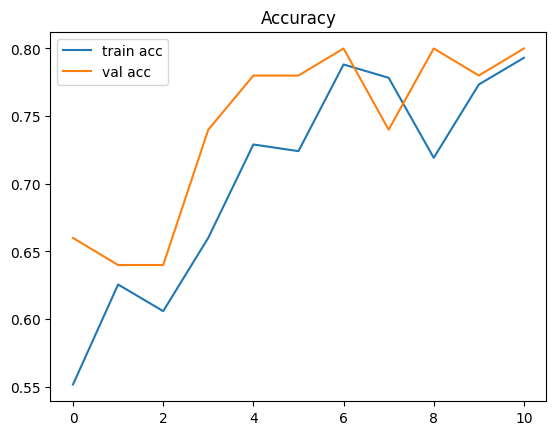

In [11]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


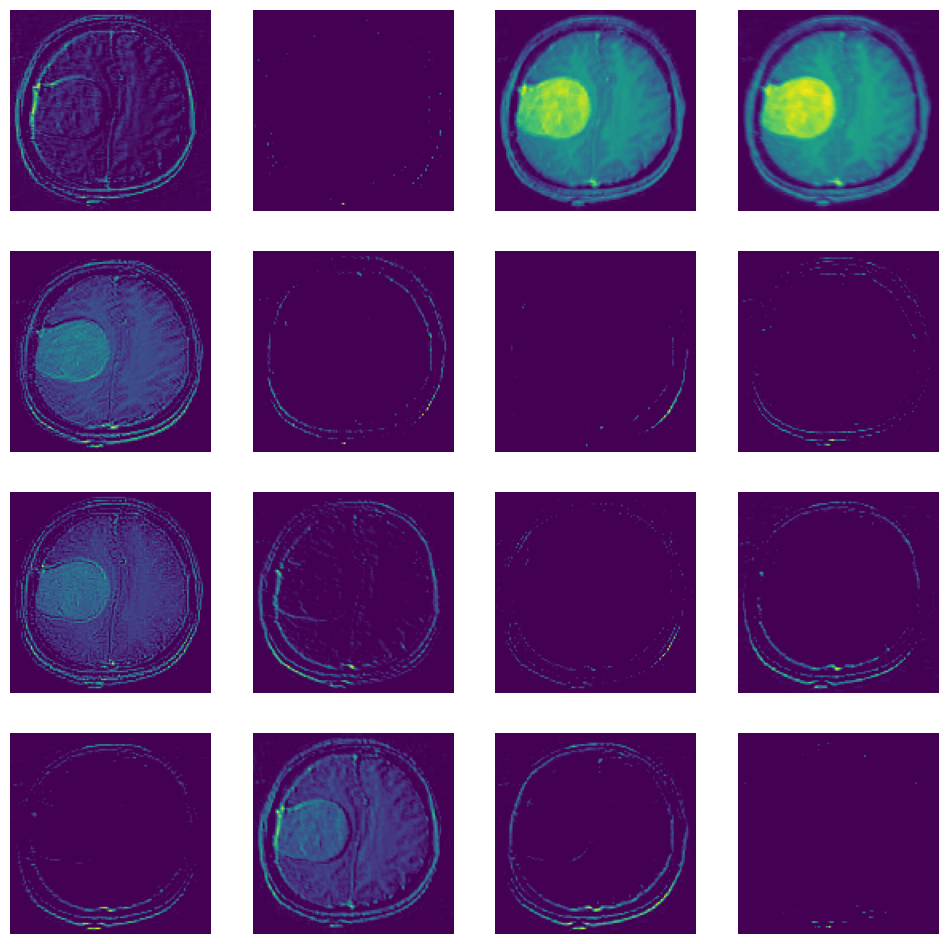

In [14]:
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]

activation_model = keras.models.Model(inputs=model.inputs, outputs=layer_outputs)

img_path = "dataset/yes/Y1.jpg"
img = keras.preprocessing.image.load_img(img_path, target_size=(128,128))
img_array = keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

activations = activation_model.predict(img_array)

layer_activation = activations[0]

plt.figure(figsize=(12,12))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(layer_activation[0,:,:,i], cmap='viridis')
    plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Using layer: conv2d_3


C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


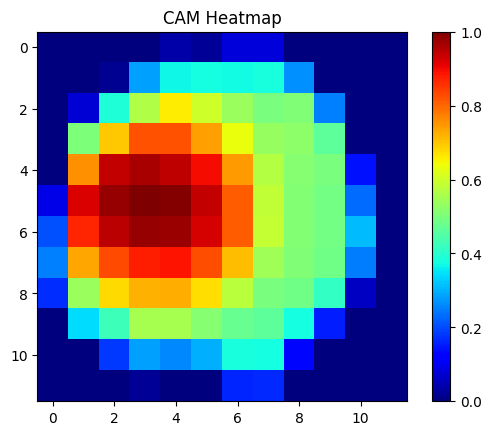

In [15]:
_ = model.predict(np.zeros((1,128,128,3)))

last_conv_layer = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer
        break

print("Using layer:", last_conv_layer.name)

grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[last_conv_layer.output, model.outputs[0]]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[:, 0]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

import matplotlib.pyplot as plt

plt.imshow(heatmap, cmap='jet')
plt.colorbar()
plt.title("CAM Heatmap")
plt.show()

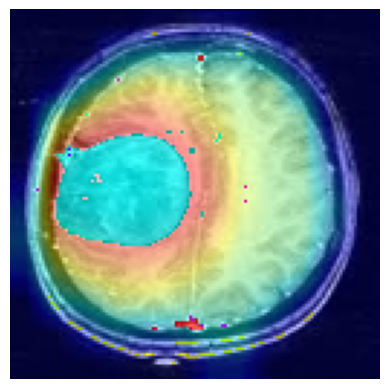

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(img_path)
img = cv2.resize(img, (128,128))

heatmap = cv2.resize(heatmap, (128,128))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

superimposed_img = cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB)

plt.imshow(superimposed_img)
plt.axis('off')
plt.show()